<a href="https://colab.research.google.com/github/MadhumantiSaha/SIH-24/blob/main/PSR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
img = cv.imread('moon.png')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

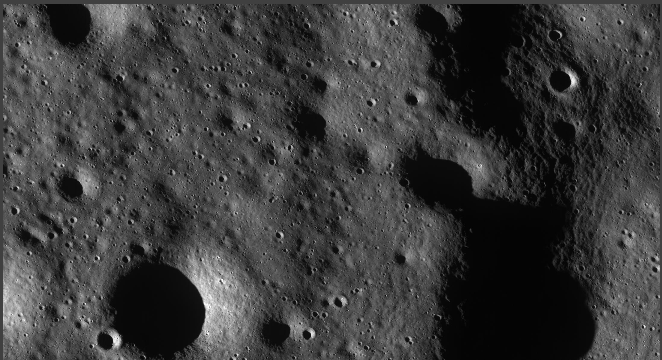

In [ ]:
cv2_imshow(img)

### Denoising (fast non-local means)

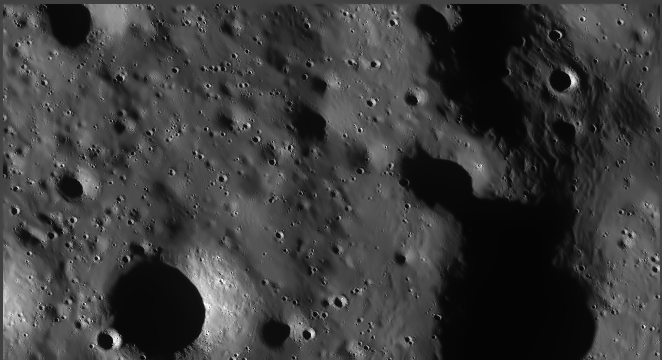

In [ ]:
denoised_img = cv.fastNlMeansDenoising(img,
                              None,
                              10, #block size used
                              7, #search window size
                              21) # h parameter: determines how similar two patches need to be to influence each other during the denoising process
cv2_imshow(denoised_img)


# Segmentation

#Functions

### Retinex algos

In [ ]:
def singleScaleRetinex(img,variance):
    retinex = np.log10(img) - np.log10(cv.GaussianBlur(img, (0, 0), variance))
    return retinex

def multiScaleRetinex(img, variance_list):
    retinex = np.zeros_like(img)
    for variance in variance_list:
        retinex += singleScaleRetinex(img, variance)
    retinex = retinex / len(variance_list)
    return retinex



def MSR(img, variance_list):
    img = np.float64(img) + 1.0
    img_retinex = multiScaleRetinex(img, variance_list)

    for i in range(img_retinex.shape[2]):
        unique, count = np.unique(np.int32(img_retinex[:, :, i] * 100), return_counts=True)
        for u, c in zip(unique, count):
            if u == 0:
                zero_count = c
                break
        low_val = unique[0] / 100.0
        high_val = unique[-1] / 100.0
        for u, c in zip(unique, count):
            if u < 0 and c < zero_count * 0.1:
                low_val = u / 100.0
            if u > 0 and c < zero_count * 0.1:
                high_val = u / 100.0
                break
        img_retinex[:, :, i] = np.maximum(np.minimum(img_retinex[:, :, i], high_val), low_val)

        img_retinex[:, :, i] = (img_retinex[:, :, i] - np.min(img_retinex[:, :, i])) / \
                               (np.max(img_retinex[:, :, i]) - np.min(img_retinex[:, :, i])) \
                               * 255
    img_retinex = np.uint8(img_retinex)
    return img_retinex



def SSR(img, variance):
    img = np.float64(img) + 1.0
    img_retinex = singleScaleRetinex(img, variance)
    for i in range(img_retinex.shape[2]):
        unique, count = np.unique(np.int32(img_retinex[:, :, i] * 100), return_counts=True)
        for u, c in zip(unique, count):
            if u == 0:
                zero_count = c
                break
        low_val = unique[0] / 100.0
        high_val = unique[-1] / 100.0
        for u, c in zip(unique, count):
            if u < 0 and c < zero_count * 0.1:
                low_val = u / 100.0
            if u > 0 and c < zero_count * 0.1:
                high_val = u / 100.0
                break
        img_retinex[:, :, i] = np.maximum(np.minimum(img_retinex[:, :, i], high_val), low_val)

        img_retinex[:, :, i] = (img_retinex[:, :, i] - np.min(img_retinex[:, :, i])) / \
                               (np.max(img_retinex[:, :, i]) - np.min(img_retinex[:, :, i])) \
                               * 255
    img_retinex = np.uint8(img_retinex)
    return img_retinex


variance_list=[15, 80, 30]
variance=300


In [ ]:
def apply_single_scale_retinex(image, kernel_size = 125):
    try:
      gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    except:
      gray=image
    gray = gray.astype(np.float32) / 255

    kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)

    illumination = cv.filter2D(gray, -1, kernel)
    retinex = np.log10(gray) - np.log10(illumination)

    # Normalize the image
    min_val = np.min(retinex)
    max_val = np.max(retinex)
    retinex = (retinex - min_val) / (max_val - min_val) * 255

    return retinex.astype(np.uint8)

In [ ]:
def apply_multi_scale_retinex(image, kernel_sizes=[125, 255, 511], weights=[0.2, 0.5, 0.3]):
    try:
      gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    except:
      gray = image
    gray = gray.astype(np.float32) / 255

    retinex_images = []
    for kernel_size, weight in zip(kernel_sizes, weights):
        kernel = np.ones((kernel_size, kernel_size)) / (kernel_size * kernel_size)
        illumination = cv.filter2D(gray, -1, kernel)
        retinex = np.log10(gray) - np.log10(illumination)
        retinex_images.append(retinex * weight)

    msr = np.sum(retinex_images, axis=0)

    # Normalize the image
    min_val = np.min(msr)
    max_val = np.max(msr)
    msr = (msr - min_val) / (max_val - min_val) * 255

    return msr.astype(np.uint8)

### Contrast Stretching

In [ ]:
def apply_contrast_stretching(image, min_val=0, max_val=255, scale_factor=1.0):
   # Convert to grayscale
    try:
      gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    except:
        gray = image

    # Find minimum and maximum pixel values
    original_min = np.min(gray)
    original_max = np.max(gray)

    # Calculate the scaling factor
    scale = (max_val - min_val) / (original_max - original_min)

    # Apply histogram stretching with optional adjustment for dark spots
    stretched = (gray - original_min) * scale
    stretched = np.uint8(stretched)

    # Adjust for dark spots (optional)
    if scale_factor > 0:
        stretched = stretched + scale_factor * (gray - original_min)

    return np.uint8(stretched)

### Scale pixel values

In [ ]:
def scale_pixel(image, val,thresh,operation=1, lower_threshold=0, upper_threshold=255,):
  try:
    gray=cv.cvtColor(image, cv.COLOR_BGR2GRAY)
  except:
    gray=image

  # Thresholding to isolate pixels within the desired range

  mask = cv.inRange(gray, lower_threshold, upper_threshold)

  # Scale the pixel values within the mask
  scaled_image = gray.copy()
  if(operation==0):
    scaled_image[mask<thresh] = scaled_image[mask<thresh] - val
    # scaled_image[mask > thresh] = scaled_image[mask > thresh] + val
  else:
    # scaled_image[mask<thresh] = scaled_image[mask<thresh] - val
    scaled_image[mask > thresh] = scaled_image[mask > thresh] + val
  return scaled_image

# Adaptive Histogram Equalization

In [ ]:
def ahe(image, clipLimit=3.0, grid=8):
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    clahe = cv.createCLAHE(clipLimit=clipLimit, #higher clipLimit allows aggressive contrast enhancement, but can introduce artifacts or halos ||  lower clipLimit: less contrast enhancement, can preserve details in the image
                           tileGridSize=(grid, grid)) # large value: More localized contrast enhancement, can be useful for preserving details in small regions || Smaller value: more global contrast enhancement, may also introduce artifacts.
    return clahe.apply(gray)

## Apply retinex algos (for low light enhancement)

In [ ]:
color_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

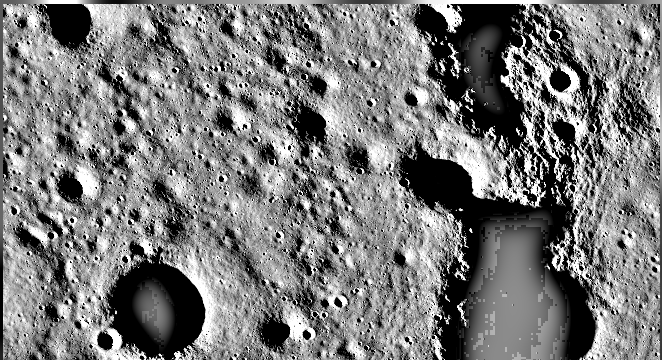

In [ ]:
cv2_imshow(SSR(color_img, variance=15))

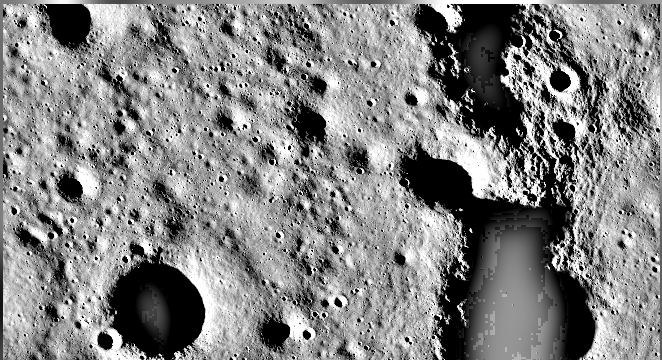

In [ ]:
cv2_imshow(SSR(color_img, variance=20))

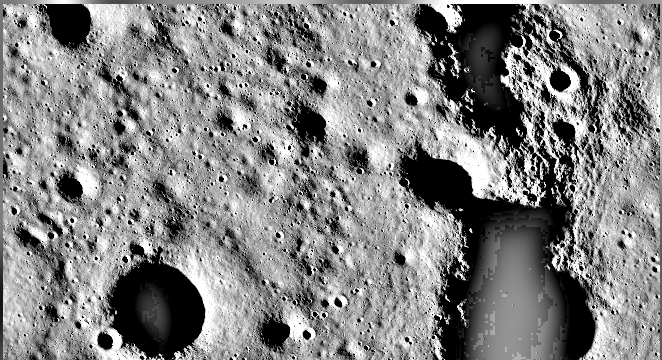

In [ ]:
cv2_imshow(MSR(color_img, variance_list=[15, 20, 25]))

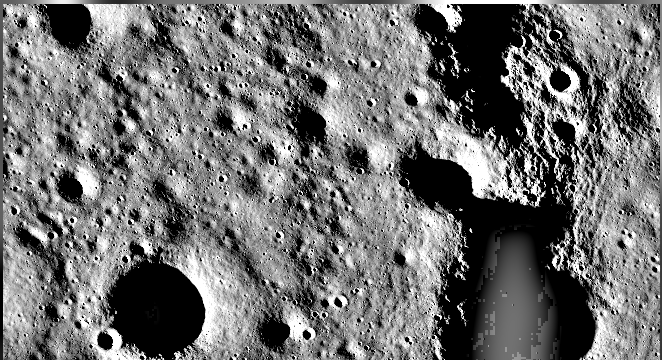

In [ ]:
cv2_imshow(MSR(color_img, variance_list=[15, 20, 30]))

In [ ]:
ret1 = SSR(color_img, variance=20)
ret2 = MSR(color_img, variance_list=[15, 20, 30])

### Adaptive histogram equalization

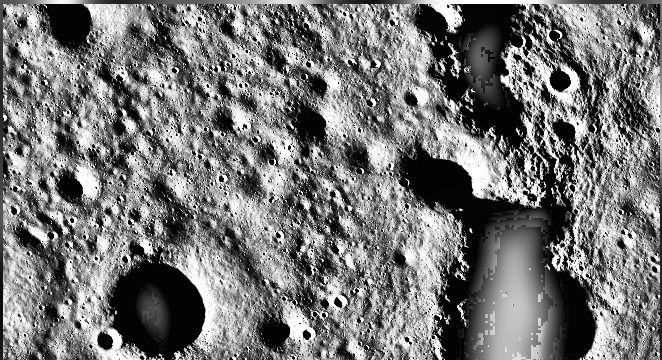

In [ ]:
cv2_imshow(ahe(ret1))

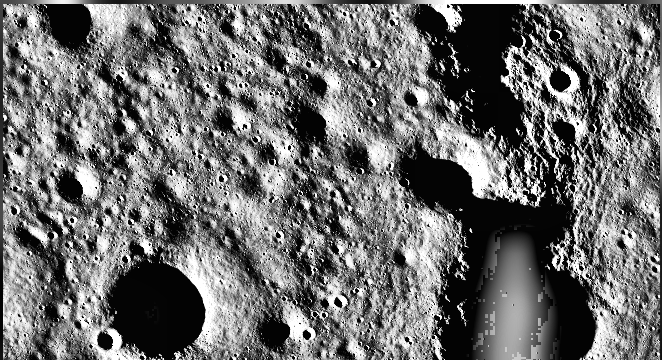

In [ ]:
cv2_imshow(ahe(ret2))

array([[120, 120, 120, ..., 162, 162, 163],
       [120, 120, 120, ..., 162, 162, 163],
       [118, 120, 120, ..., 162, 162, 162],
       ...,
       [ 71,  71,  71, ..., 203,  72,  16],
       [ 71,  71,  71, ..., 214,  72,  16],
       [ 71,  71,  71, ..., 230,  72,  16]], dtype=uint8)
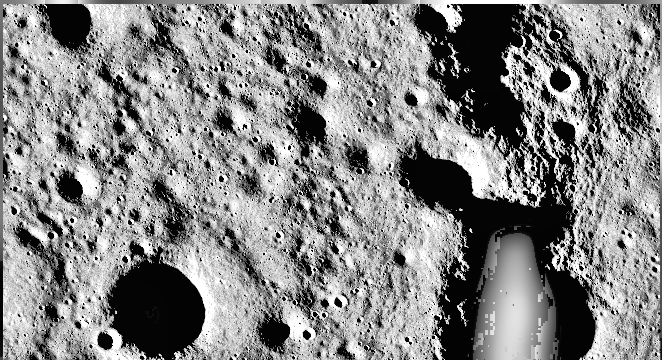

In [ ]:
cont_img = ahe(ret2)

scale_pixel(image = cont_img,thresh=100, val=50, operation=1, lower_threshold=20, upper_threshold=180)

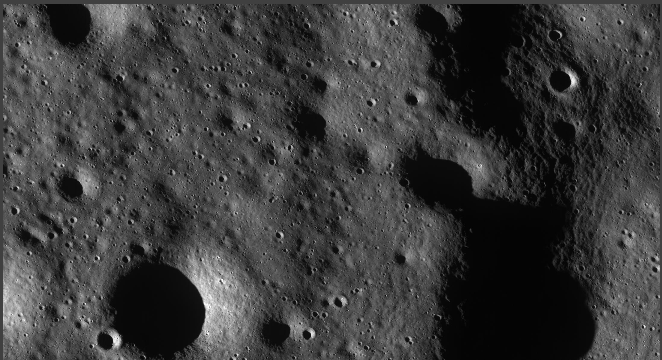

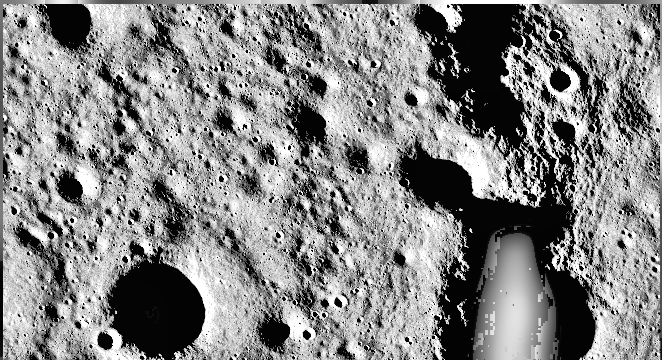

In [ ]:
cv2_imshow(img)
cv2_imshow(scale_pixel(image = cont_img,thresh=100, val=50, operation=1, lower_threshold=20, upper_threshold=180))